In [1]:
import pandas as pd
import numpy as np
#import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#import networkx as nx
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import TwoSlopeNorm

In [2]:
from Functions import df_xr_prep, lin_model_fast, conditioning_everything_fast, var_prepper

In [3]:
#load drivers and mediators from data_ready
#SON
era_SON_Andes_df=pd.read_csv('~/work/data_ready/5_with_VB.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('~/work/data_ready/4_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 8kB
Dimensions:        (year: 73)
Coordinates:
  * year           (year) int64 584B 1951 1952 1953 1954 ... 2022 2023 2024 1950
Data variables: (12/13)
    t_Andes        (year) float64 584B -1.791 0.5614 -0.2617 ... 0.6017 nan
    precip_Andes   (year) float64 584B 0.129 0.4549 -1.375 ... -0.2223 -1.51 nan
    ENSO           (year) float64 584B -0.6866 0.5838 0.3068 ... 1.632 nan
    IOD            (year) float64 584B 0.2555 0.6281 1.26 ... 0.9651 4.209 nan
    EDJ            (year) float64 584B 1.783 0.6677 -0.5056 ... 0.1875 nan
    EDJ_lat        (year) float64 584B -0.6985 1.359 -0.9556 ... -2.241 nan
    ...             ...
    SPV            (year) float64 584B 0.2633 -0.6312 1.451 ... 1.702 1.85 nan
    A_SAM          (year) float64 584B 0.233 -1.135 -2.197 ... 1.774 0.05365 nan
    S_SAM          (year) float64 584B 0.6038 -1.058 0.1437 ... 1.93 1.88 nan
    IOBW           (year) float64 584B -1.546 0.8591 -0.3374 ... 2.389 nan
    VB             (year) float64 584B -0.0653 -0.101 0.2247 ... 0.7241 nan
    VB_class       (year) object 584B 'Early' 'Early' 'Late' ... 'Late' 'Early'

In [4]:
##import station data
precip_obs=xr.open_dataset('~/work/Obs_data_ready/obs_data_precip_gapfilled.nc')
temp_obs=xr.open_dataset('~/work/Obs_data_ready/obs_data_temp_gapfilled.nc')

#print(precip_obs)
mask = (
    (precip_obs.lat >= -55) &
    (precip_obs.lat <= -20) &
    (precip_obs.lon >= -76) &
    (precip_obs.lon <= -50)
)

mask_t=(
    (temp_obs.lat >= -55) &
    (temp_obs.lat <= -20) &
    (temp_obs.lon >= -76) &
    (temp_obs.lon <= -50)
)

ds_region = precip_obs.sel(points=mask)
ds_region_t=temp_obs.sel(points=mask_t)

obs_temp_sel=ds_region_t.sel(time=slice('1950','2024'))
obs_precip_sel=ds_region.sel(time=slice('1950','2024'))
display(obs_temp_sel)

<xarray.Dataset> Size: 3MB
Dimensions:      (time: 817, points: 456)
Coordinates:
  * time         (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2018-01-01
  * points       (points) <U11 20kB '1050007' '1740002' ... 'ARM00087938'
    lat          (points) float64 4kB -20.05 -20.07 -20.13 ... -53.78 -54.84
    lon          (points) float64 4kB -68.81 -69.27 -69.75 ... -67.75 -68.3
Data variables:
    temperature  (time, points) float64 3MB ...

In [5]:
##SON data

obs_precip_SON=var_prepper(obs_precip_sel, [9,10,11])
obs_precip_DJF=var_prepper(obs_precip_sel, [12,1,2])

obs_temp_SON=var_prepper(obs_temp_sel, [9,10,11])
obs_temp_DJF=var_prepper(obs_temp_sel, [12,1,2])

/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


<xarray.Dataset> Size: 560kB
Dimensions:  (year: 68, points: 927)
Coordinates:
  * points   (points) <U11 41kB '1042002' '1740001' ... 'ARM00087938'
    lat      (points) float64 7kB -20.0 -20.01 -20.05 ... -51.82 -53.78 -54.84
    lon      (points) float64 7kB -68.57 -69.2 -68.81 ... -58.45 -67.75 -68.3
  * year     (year) int64 544B 1950 1951 1952 1953 1954 ... 2014 2015 2016 2017
Data variables:
    precip   (year, points) float64 504kB nan nan nan nan ... 0.04431 nan 0.2269


/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


<xarray.Dataset> Size: 568kB
Dimensions:  (year: 69, points: 927)
Coordinates:
  * points   (points) <U11 41kB '1042002' '1740001' ... 'ARM00087938'
    lat      (points) float64 7kB -20.0 -20.01 -20.05 ... -51.82 -53.78 -54.84
    lon      (points) float64 7kB -68.57 -69.2 -68.81 ... -58.45 -67.75 -68.3
  * year     (year) int64 552B 1950 1951 1952 1953 1954 ... 2015 2016 2017 2018
Data variables:
    precip   (year, points) float64 512kB nan nan nan ... -0.4699 nan -0.4713
<xarray.Dataset> Size: 276kB
Dimensions:      (year: 68, points: 456)
Coordinates:
  * points       (points) <U11 20kB '1050007' '1740002' ... 'ARM00087938'
    lat          (points) float64 4kB -20.05 -20.07 -20.13 ... -53.78 -54.84
    lon          (points) float64 4kB -68.81 -69.27 -69.75 ... -67.75 -68.3
  * year         (year) int64 544B 1950 1951 1952 1953 ... 2014 2015 2016 2017
Data variables:
    temperature  (year, points) float64 248kB nan nan nan ... -0.4948 -0.226
<xarray.Dataset> Size: 280kB
Dimension

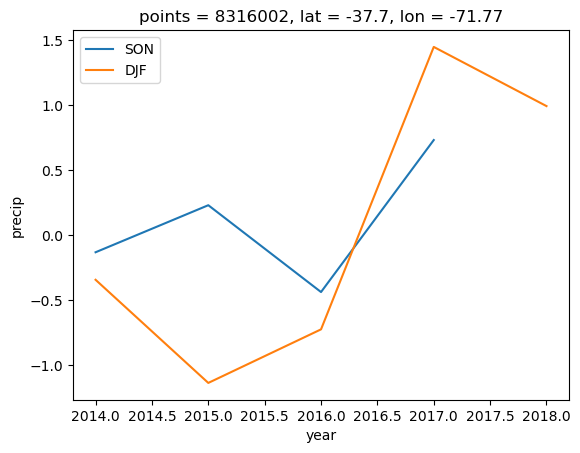

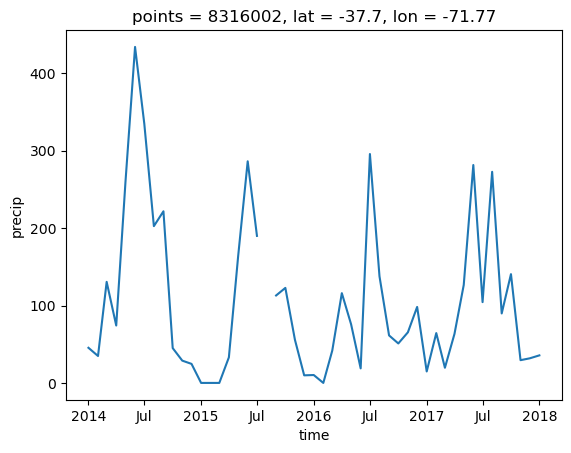

In [6]:
##sanity check for data
p=498
a=obs_precip_SON.isel(points=p)
b=obs_precip_DJF.isel(points=p)
a['precip'].plot(label='SON')
b['precip'].plot(label='DJF')
plt.legend()
plt.show()
obs_precip_sel.isel(points=p)['precip'].plot()
plt.show()


In [7]:
#merge indices and obs dataarrays
ds_SON=xr.merge([obs_precip_SON,obs_temp_SON, era_SON_Andes_array])
ds_DJF=xr.merge([obs_precip_DJF, obs_temp_DJF, era_DJF_Andes_array])

display(ds_SON)

<xarray.Dataset> Size: 1MB
Dimensions:        (points: 986, year: 74)
Coordinates:
  * points         (points) <U11 43kB '10100002' '10100004' ... 'UYM00086580'
  * year           (year) int64 592B 1950 1951 1952 1953 ... 2021 2022 2023 2024
    lat            (points) float64 8kB -39.87 -40.02 -39.87 ... -34.46 -34.84
    lon            (points) float64 8kB -71.89 -71.72 -71.89 ... -57.77 -56.03
Data variables: (12/13)
    precip         (year, points) float64 584kB nan 3.572 nan ... nan nan nan
    temperature    (year, points) float64 584kB nan nan nan nan ... nan nan nan
    t_Andes        (year) float64 592B nan -1.453 -0.07061 ... -2.693 -0.1758
    precip_Andes   (year) float64 592B nan 0.8738 -2.068 ... 0.6476 1.215
    ENSO           (year) float64 592B nan 0.8577 -0.08958 ... 1.719 -0.33
    IOD            (year) float64 592B nan 0.1126 -0.4963 ... 3.25 0.8168
    ...             ...
    EDJ_lat        (year) float64 592B nan 1.568 -1.369 ... -1.859 -0.1452 1.446
    EDJ_lat_nostd  (year) float64 592B nan -48.64 -53.79 ... -51.64 -48.86
    SPV            (year) float64 592B nan -1.639 0.7289 ... 0.9296 -0.05547
    A_SAM          (year) float64 592B nan -0.6832 0.7533 ... -0.6919 -0.4684
    S_SAM          (year) float64 592B nan -2.402 -0.386 ... 2.036 0.5597 0.9627
    VB_class       (year) object 592B 'Early' 'Early' 'Early' ... 'Early' 'Late'

In [8]:
import cartopy.feature as cfeature
def modified_colorbar(cmap, levels, center_zero=True):
    n = len(levels) - 1
    colors = cmap(np.linspace(0, 1, n))
    
    if center_zero:
        mid = n // 2
        if n % 2 == 0: ##for even number of levels, set the two middle colors to white
            colors[mid-1:mid+1] = [1, 1, 1, 1]
        else:
            colors[mid] = np.array([1, 1, 1, 1])  # white
    
    return mcolors.ListedColormap(colors)

def plot_map_obs_only(
    i,
    da,
    title,
    units,
    fig,
    subplts_num,
    cmap=plt.cm.viridis,
    cbar_each=None,
    levels=None,
    fontsize=14,
    smooth=False,
    stations=None
):
    """
    Plot a regional map using only the spatial extent of da with PlateCarree.

    Parameters
    ----------
    da : xarray.DataArray
        DataArray with dimensions (lat, lon)
    stations: Regressed Station data
    """
    # Extract coordinates
    lat = da.lat.values
    lon = da.lon.values
    #print(lat)
    
    arr = da.values.astype(float)
    #arr = np.clip(arr, -max_abs, max_abs)

    # Create axis with PlateCarree projection
    ax = fig.add_subplot(1, subplts_num, i, projection=ccrs.PlateCarree())

    # Set extent to data region only
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())


    # Colormap normalization
    # ---- FIX: always center at zero ----
    if cbar_each is None:
        vmax = np.nanmax(np.abs(arr))
        if stations is not None:
            station_max=np.nanmax(np.abs(stations))
            global_max=np.max(vmax, station_max)
    else:
        vmax=cbar_each
    if levels is None:
        levels = np.arange(-3, 3.01, 0.5)  # include +3
    
    cmap_mod=modified_colorbar(cmap, levels, center_zero=True)
    norm = BoundaryNorm(levels, ncolors=cmap_mod.N, clip=True)

    
    # 2. Skalierung berechnen
    amps=arr
    min_amp = np.nanmin(amps)
    max_amp = np.nanmax(amps)
    min_size = 20  # Kleinster Durchmesser in Punkt
    max_size = 150 # Größter Durchmesser in Punkt

    # Normalisierung auf die gewünschte Größe
    sizes = []
    for a in amps:
            if max_amp == min_amp:
                sizes.append(min_size) # Vermeiden durch Division durch 0
            else:
                normalized = (a - min_amp) / (max_amp - min_amp)
                sizes.append(min_size + (max_size - min_size) * normalized)
    # 4. Kreise plotten
    cs=ax.scatter(lon, lat, s=sizes, c=amps,cmap=cmap_mod, norm=norm,\
                   edgecolors='black', 
                transform=ccrs.PlateCarree(), label='Stations')
        

    ax.coastlines(resolution="50m")        # still keep coastlines
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)  # add country borders

    # Title
    ax.text(0.01, 1.02, title, transform=ax.transAxes, fontsize=fontsize)
    ax.set_adjustable('box')

    # Colorbar
    # ---- individual colorbars ----
    if cbar_each is None:
        cbar_ax = ax.inset_axes([0.05, -0.12, 0.9, 0.07])
        cbar = plt.colorbar(cs, orientation="horizontal", cax=cbar_ax,fraction=0.046,
                pad=0.08)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_ticks(levels)
        cbar.set_label(units, fontsize=fontsize)

    
    if stations is not None:
        # 2. Skalierung berechnen
        amps=stations.values
        min_amp = min(amps)
        max_amp = max(amps)
        min_size = 20  # Kleinster Durchmesser in Punkt
        max_size = 150 # Größter Durchmesser in Punkt

        # Normalisierung auf die gewünschte Größe
        sizes = []
        for a in amps:
            if max_amp == min_amp:
                sizes.append(min_size) # Vermeiden durch Division durch 0
            else:
                normalized = (a - min_amp) / (max_amp - min_amp)
                sizes.append(min_size + (max_size - min_size) * normalized)

        # 4. Kreise plotten
        ax.scatter(stations.lon, stations.lat, s=sizes, c='blue', edgecolors='black', alpha=0.6, 
                transform=ccrs.PlateCarree(), label='Stations')
    
    return cs

###############################################################################################
#         
def subplots_map_obs_only(ds, title_list, cmap=plt.cm.RdBu.reversed(), unit='K', steps=0.1, \
                 cbar_each=None, heading=None, global_max_val=0.0):
    cs_list=[]
    fontsize=16
    
    global_max=0
    for da in ds:
        local_max = np.nanmax(np.abs(da.values))
        global_max = max(global_max, local_max)
    if global_max<global_max_val: #if the global max is lower than the provided levels, we need to adjust them
        global_max=global_max_val
        
    #Define levels for colorbar later
    step = steps # or 0.25 if you prefer
    max_abs = np.ceil(global_max / step) * step
    #print(max_abs)
    #levels = np.round(np.arange(-max_abs, max_abs + step, step), decimals=2)  
    levels = np.linspace(
    -max_abs,
    max_abs,
    int(2 * max_abs / step) + 1
    )
    
    ##Find optimal figsize
    width_per_plot = 4
    height = 5 

    fig = plt.figure(figsize=(len(ds) * width_per_plot, height))
    fig.subplots_adjust(top=0.8)
    
    for j, da in enumerate(ds):
        
        cs=plot_map_obs_only( #get the colorbar for each subplot
        i=j+1,
        da=da,
        title=title_list[j],
        units=unit,
        cbar_each=global_max,
        fig=fig,
        subplts_num=len(ds),
        cmap=cmap,
        levels=levels,
        smooth=False,
        fontsize=fontsize)
        
        cs_list.append(cs)
    
    plt.tight_layout(rect=[0, 0.12, 1, 0.92])
    
    #if global_max>levels[-1]: #if the global max exceeds the provided levels, we need to adjust them
    
    
    if not cbar_each:
        #modify colorbar
        cmap_mod = modified_colorbar(cmap, levels, center_zero=True)

        # create independent global norm
        global_norm = BoundaryNorm(levels, ncolors=cmap_mod.N, clip=True)

        sm = cm.ScalarMappable(norm=global_norm, cmap=cmap_mod)
        sm.set_array([])
        
        cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.03])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
        ticks = np.arange(-max_abs, max_abs + step, step*2)  
        cbar.set_ticks(ticks)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(unit, fontsize=fontsize)
                
    ##Heading
    if heading:
        fig.suptitle(heading, y=1.1, fontweight='bold', fontsize=18)
        fig.savefig('target_maps_whole/'+heading+'.jpg', dpi=300, bbox_inches='tight')
    
    plt.show()

In [9]:
precip_SON_direct=conditioning_everything_fast(ds_SON, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], \
                                               'precip')

temp_SON_direct=conditioning_everything_fast(ds_SON, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], \
                                               'temperature')

precip_SON_tot=conditioning_everything_fast(ds_SON, ['ENSO', 'IOD', 'SPV'], 'precip',total_eff=True)
temp_SON_tot=conditioning_everything_fast(ds_SON, ['ENSO', 'IOD', 'SPV'], 'temperature', total_eff=True)

ENSO done
IOD done
SPV done
A_SAM done
S_SAM done
ENSO done
IOD done
SPV done
A_SAM done
S_SAM done
ENSO done
IOD done
SPV done
ENSO done
IOD done
SPV done


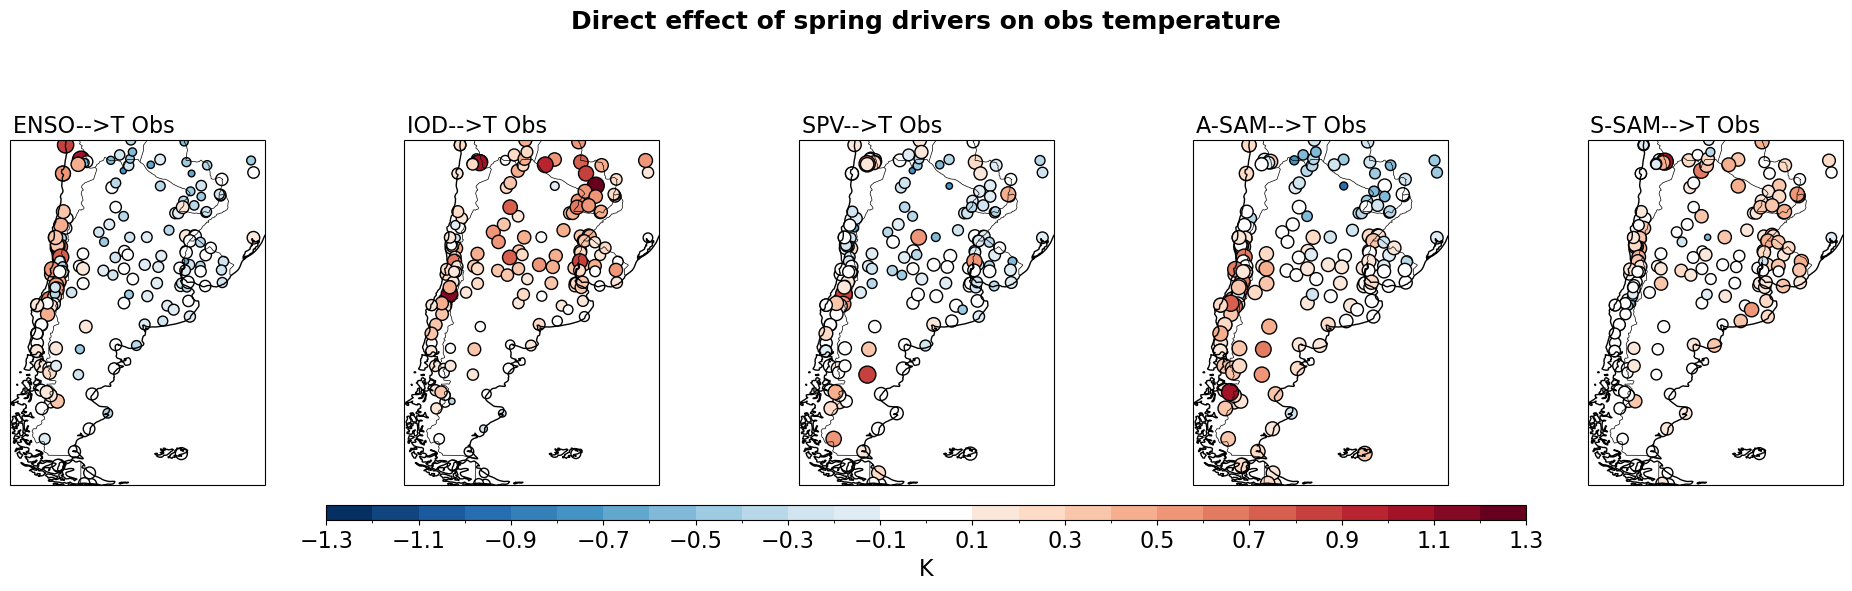

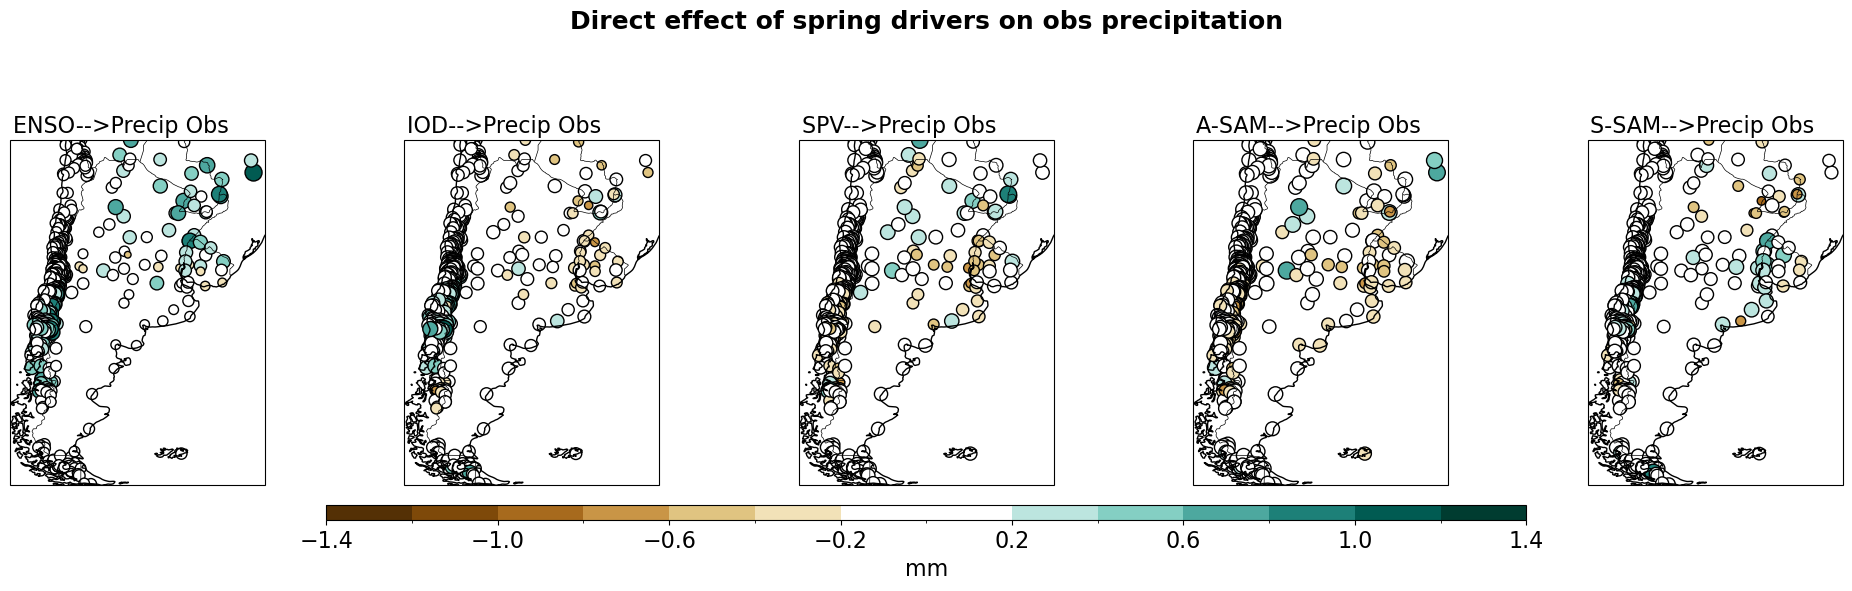

In [10]:
title_temp_list=['ENSO-->T Obs', 'IOD-->T Obs', 'SPV-->T Obs', 'A-SAM-->T Obs', 'S-SAM-->T Obs']
title_pr_list=['ENSO-->Precip Obs', 'IOD-->Precip Obs', 'SPV-->Precip Obs', 'A-SAM-->Precip Obs', 'S-SAM-->Precip Obs']
subplots_map_obs_only(temp_SON_direct, title_temp_list, cmap=plt.cm.RdBu_r, unit='K', steps=.1,
                      heading='Direct effect of spring drivers on obs temperature')
subplots_map_obs_only(precip_SON_direct, title_pr_list, cmap=plt.cm.BrBG, unit='mm', steps=.2,
                      heading='Direct effect of spring drivers on obs precipitation')

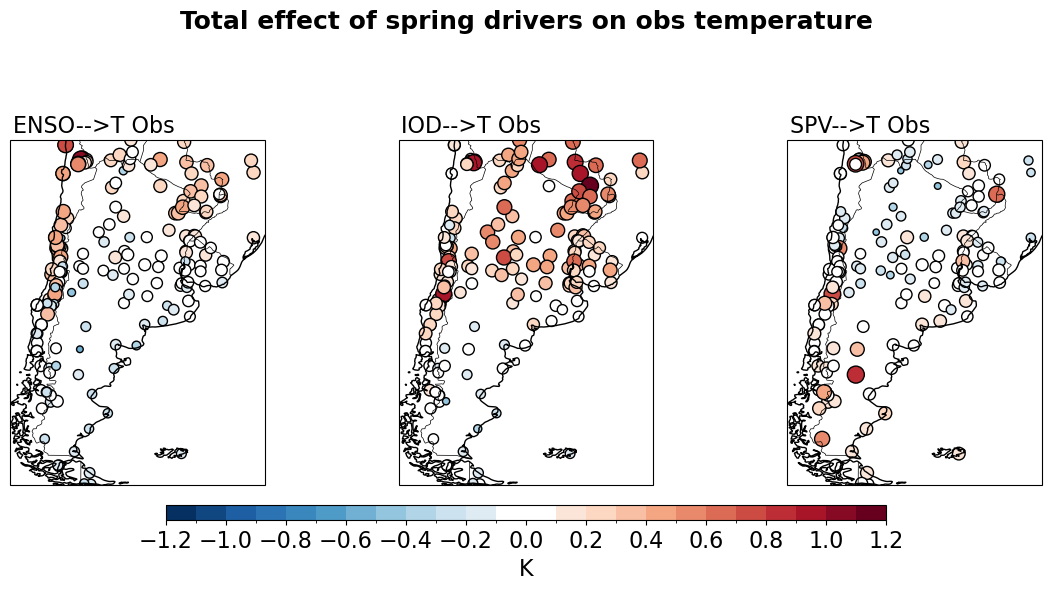

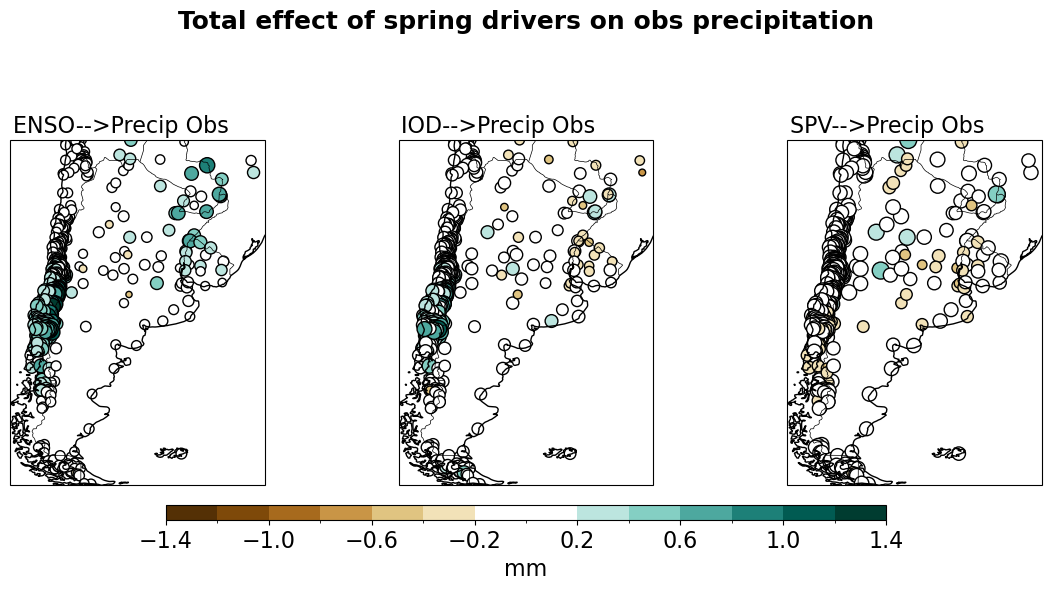

In [11]:
title_temp_list_tot=['ENSO-->T Obs', 'IOD-->T Obs', 'SPV-->T Obs']
title_pr_list_tot=['ENSO-->Precip Obs', 'IOD-->Precip Obs', 'SPV-->Precip Obs']
subplots_map_obs_only(temp_SON_tot, title_temp_list_tot, cmap=plt.cm.RdBu_r, unit='K', steps=.1,
                      heading='Total effect of spring drivers on obs temperature')
subplots_map_obs_only(precip_SON_tot, title_pr_list_tot, cmap=plt.cm.BrBG, unit='mm', steps=.2,
                      heading='Total effect of spring drivers on obs precipitation')

DJF

In [12]:
precip_DJF_direct=conditioning_everything_fast(ds_DJF, ['ENSO', 'IOBW', 'VB', 'A_SAM', 'S_SAM'], \
                                               'precip')

temp_DJF_direct=conditioning_everything_fast(ds_DJF, ['ENSO', 'IOBW', 'VB', 'A_SAM', 'S_SAM'], \
                                               'temperature')

precip_DJF_tot=conditioning_everything_fast(ds_DJF, ['ENSO', 'IOBW', 'VB'], 'precip',total_eff=True)
temp_DJF_tot=conditioning_everything_fast(ds_DJF, ['ENSO', 'IOBW', 'VB'], 'temperature', total_eff=True)

ENSO done
IOBW done
VB done
A_SAM done
S_SAM done
ENSO done
IOBW done
VB done
A_SAM done
S_SAM done
ENSO done
IOBW done
VB done
ENSO done
IOBW done
VB done


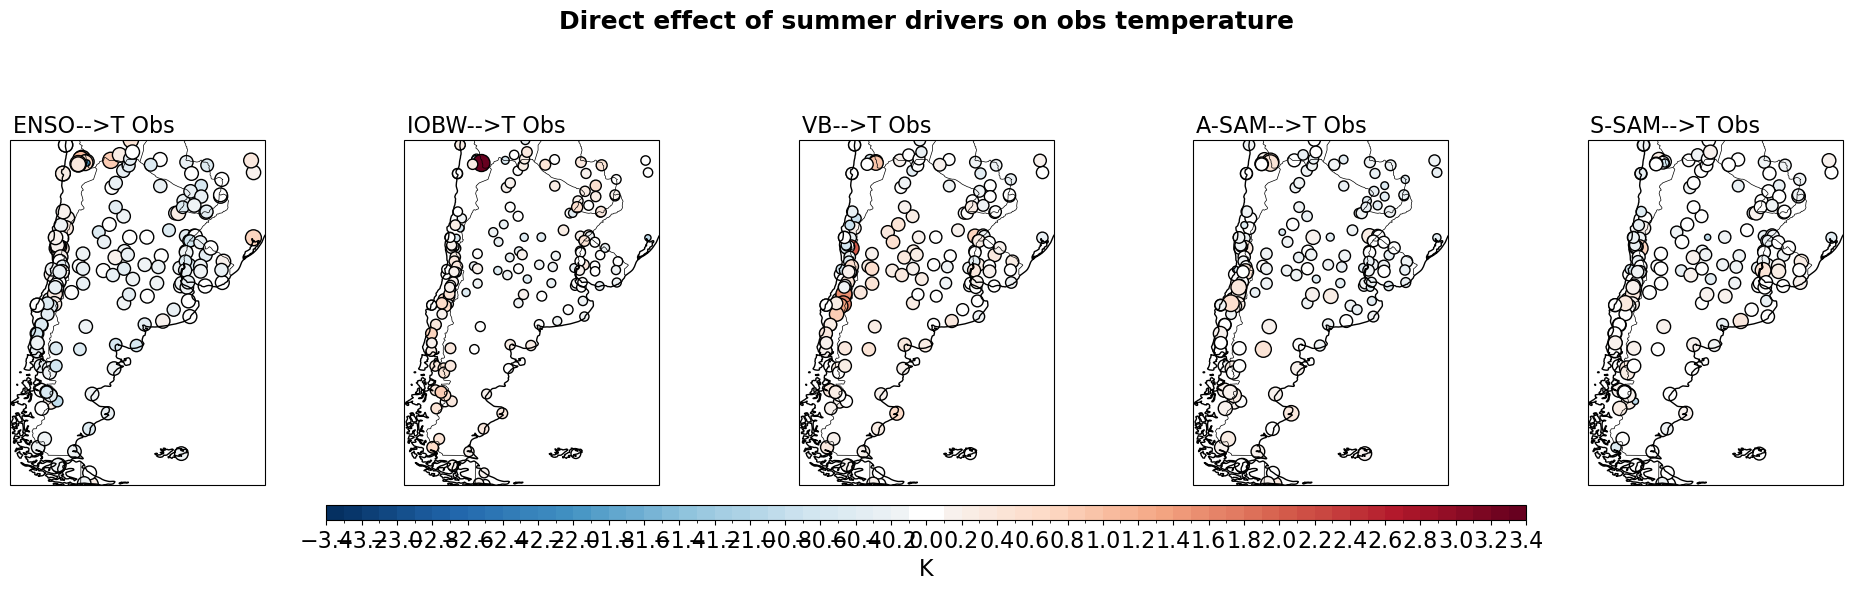

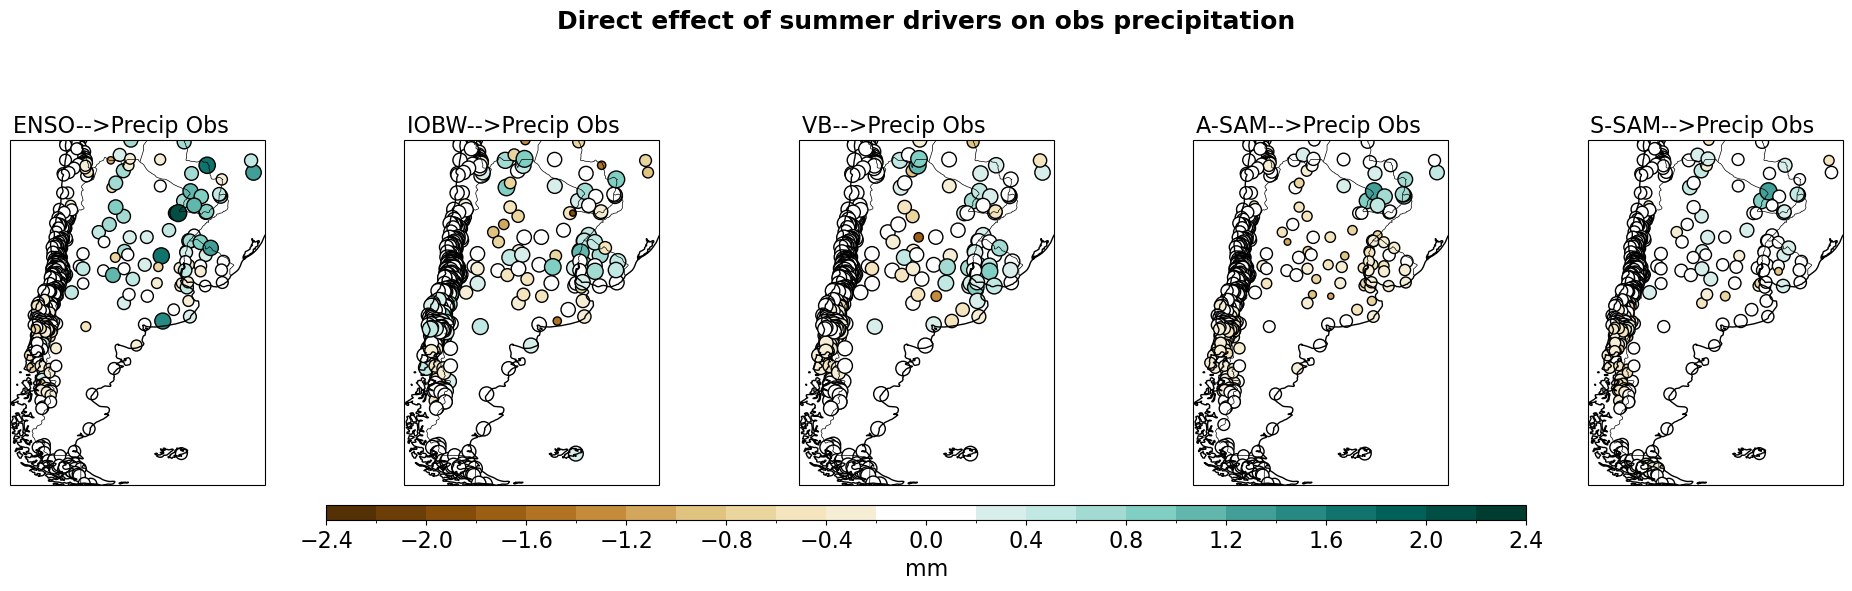

In [13]:
title_temp_list_DJF=['ENSO-->T Obs', 'IOBW-->T Obs', 'VB-->T Obs', 'A-SAM-->T Obs', 'S-SAM-->T Obs']
title_pr_list_DJF=['ENSO-->Precip Obs', 'IOBW-->Precip Obs', 'VB-->Precip Obs', 'A-SAM-->Precip Obs', 'S-SAM-->Precip Obs']
subplots_map_obs_only(temp_DJF_direct, title_temp_list_DJF, cmap=plt.cm.RdBu_r, unit='K', steps=.1,
                      heading='Direct effect of summer drivers on obs temperature')
subplots_map_obs_only(precip_DJF_direct, title_pr_list_DJF, cmap=plt.cm.BrBG, unit='mm', steps=.2,
                      heading='Direct effect of summer drivers on obs precipitation')

Now try to plot the ERA5 data together with obs dots on top

In [14]:
t_era=xr.open_dataset('~/work/data/era5_t2m.nc') #variable name is t2m
t_era=t_era.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
t_total=t_era.sel(time=slice('1950','2024'),lat=slice(-20,-55),lon=slice(-76,-49)) 

t_whole_SON=var_prepper(t_total, [9,10,11], wghts_bool=False)
t_whole_DJF=var_prepper(t_total, [12,1,2], wghts_bool=False)

#Era 5 precip data
pr_era=xr.open_dataset('~/work/data/era5_tp.nc')
pr_era=pr_era.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
pr_total=pr_era.sel(time=slice('1950','2024'),lat=slice(-20,-55),lon=slice(-76,-49)) 

pr_whole_SON=var_prepper(pr_total, [9,10,11], wghts_bool=False)
pr_whole_DJF=var_prepper(pr_total, [12,1,2], wghts_bool=False)

<xarray.Dataset> Size: 9MB
Dimensions:  (year: 75, lat: 141, lon: 105)
Coordinates:
  * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
  * lon      (lon) float64 840B -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t2m      (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan nan
<xarray.Dataset> Size: 9MB
Dimensions:  (year: 76, lat: 141, lon: 105)
Coordinates:
  * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
  * lon      (lon) float64 840B -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0
  * year     (year) int64 608B 1950 1951 1952 1953 1954 ... 2022 2023 2024 2025
Data variables:
    t2m      (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan nan
<xarray.Dataset> Size: 9MB
Dimensions:  (year: 75, lat: 141, lon: 105)
Coordinates:
  * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.

In [15]:
ds_SON=xr.merge([ds_SON, t_whole_SON, pr_whole_SON])
display(ds_SON)

ds_DJF=xr.merge([ds_DJF, pr_whole_DJF, t_whole_DJF])

<xarray.Dataset> Size: 19MB
Dimensions:        (points: 986, year: 75, lat: 141, lon: 105)
Coordinates:
  * points         (points) <U11 43kB '10100002' '10100004' ... 'UYM00086580'
  * year           (year) int64 600B 1950 1951 1952 1953 ... 2021 2022 2023 2024
  * lat            (lat) float64 1kB -20.0 -20.25 -20.5 ... -54.5 -54.75 -55.0
  * lon            (lon) float64 840B -76.0 -75.75 -75.5 ... -50.5 -50.25 -50.0
Data variables: (12/15)
    precip         (year, points) float64 592kB nan 3.572 nan ... nan nan nan
    temperature    (year, points) float64 592kB nan nan nan nan ... nan nan nan
    t_Andes        (year) float64 600B nan -1.453 -0.07061 ... -2.693 -0.1758
    precip_Andes   (year) float64 600B nan 0.8738 -2.068 ... 0.6476 1.215
    ENSO           (year) float64 600B nan 0.8577 -0.08958 ... 1.719 -0.33
    IOD            (year) float64 600B nan 0.1126 -0.4963 ... 3.25 0.8168
    ...             ...
    SPV            (year) float64 600B nan -1.639 0.7289 ... 0.9296 -0.05547
    A_SAM          (year) float64 600B nan -0.6832 0.7533 ... -0.6919 -0.4684
    S_SAM          (year) float64 600B nan -2.402 -0.386 ... 2.036 0.5597 0.9627
    VB_class       (year) object 600B 'Early' 'Early' 'Early' ... 'Early' 'Late'
    t2m            (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan
    tp             (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan

In [16]:
from Functions import plot_map, subplots_map

print(precip_SON_direct[0].lon.max())

#print(era5_reg_precip_SON[0].lon.max())

<xarray.DataArray 'lon' ()> Size: 8B
array(-50.)


ENSO done
IOD done
SPV done
A_SAM done
S_SAM done


(<cartopy.mpl.geocollection.GeoQuadMesh at 0x7f5ee61abf40>,
 <matplotlib.collections.PathCollection at 0x7f5ee5e618d0>)

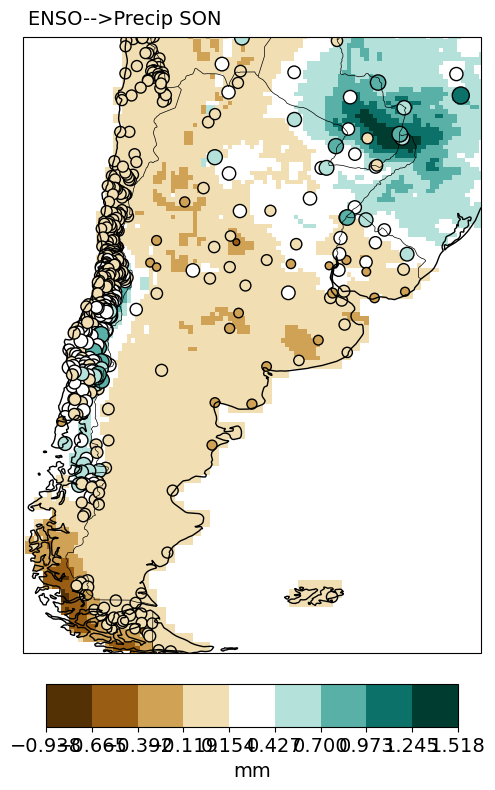

In [17]:
era5_reg_precip_SON=conditioning_everything_fast(ds_SON, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 
                                                 'tp')

plot_map(1, era5_reg_precip_SON[0], 'ENSO-->Precip SON', units='mm', fig=plt.figure(figsize=(6,8)), subplts_num=1, cmap=plt.cm.BrBG, \
         levels=np.linspace(np.nanmin(era5_reg_precip_SON[0]), np.nanmax(era5_reg_precip_SON[0]), 10), 
         stations=precip_SON_direct[0])

In [18]:
era5_reg_temp_SON=conditioning_everything_fast(ds_SON, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 
                                                 't2m')
era5_reg_temp_SON_tot=conditioning_everything_fast(ds_SON, ['ENSO', 'IOD', 'SPV'], 't2m', total_eff=True)
era5_reg_precip_SON_tot=conditioning_everything_fast(ds_SON, ['ENSO', 'IOD', 'SPV'], 'tp', total_eff=True)

ENSO done
IOD done
SPV done
A_SAM done
S_SAM done
ENSO done
IOD done
SPV done
ENSO done
IOD done
SPV done


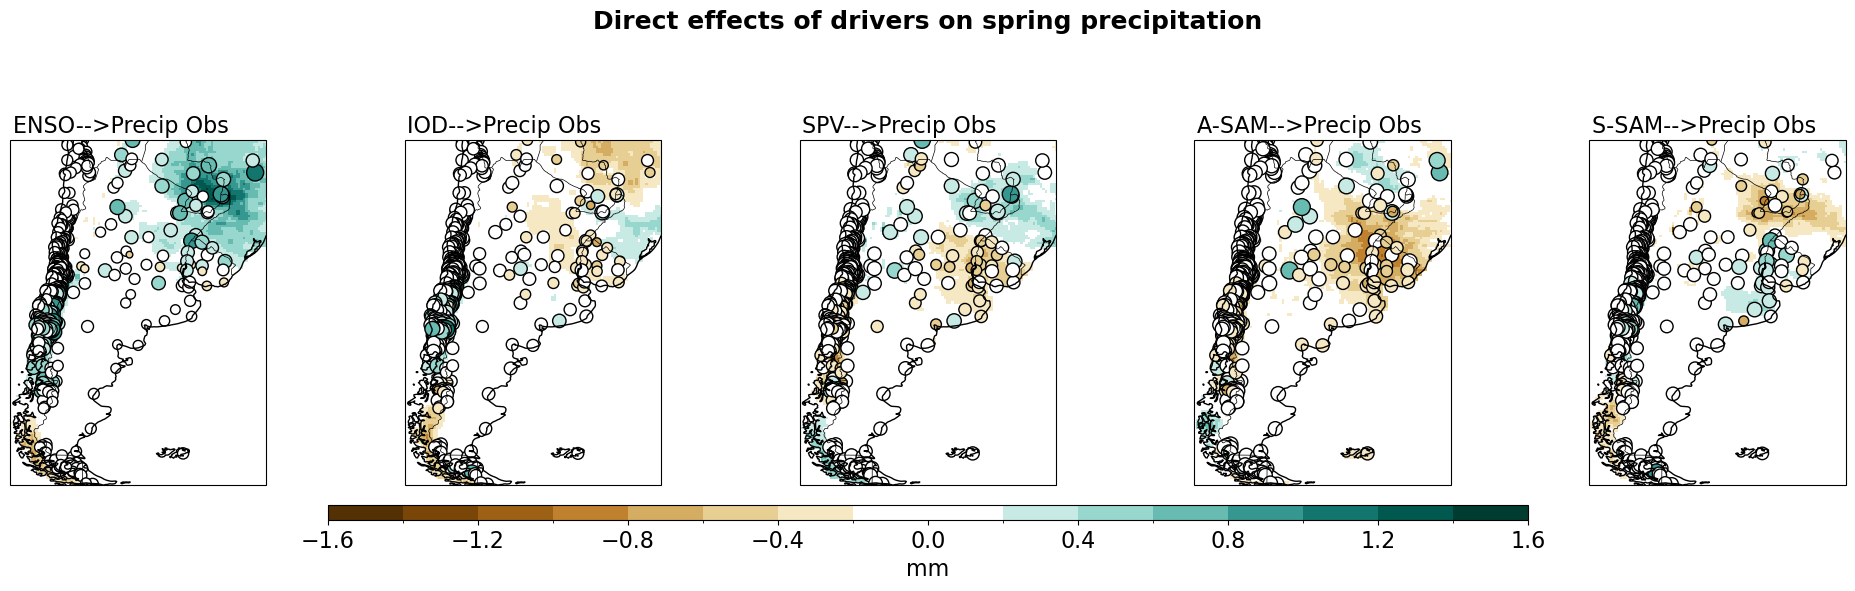

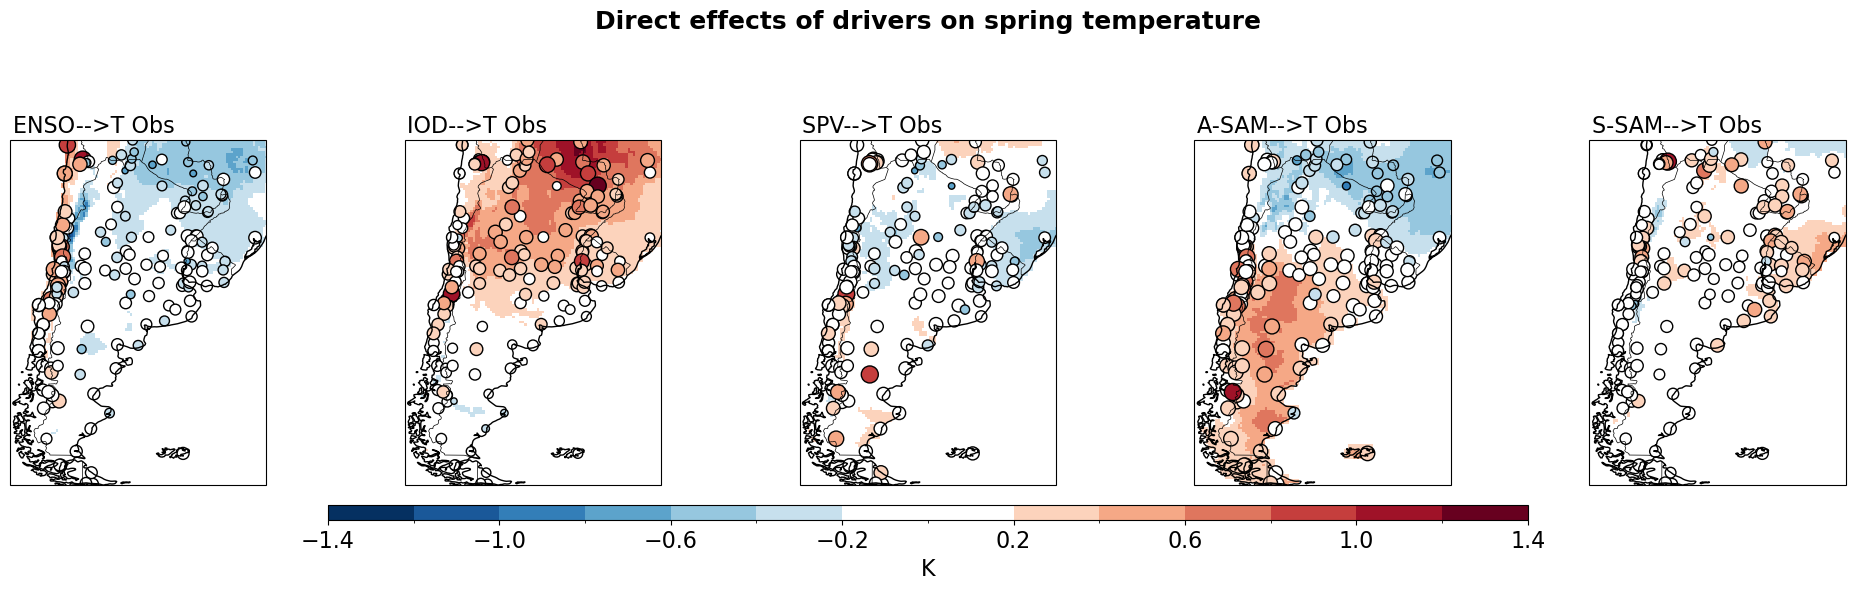

In [19]:
subplots_map(era5_reg_precip_SON, title_pr_list, cmap=plt.cm.BrBG, unit='mm', steps=.2, heading='Direct effects of drivers on spring precipitation', \
             stations=precip_SON_direct)

subplots_map(era5_reg_temp_SON, title_temp_list, cmap=plt.cm.RdBu_r, unit='K', steps=.2, heading='Direct effects of drivers on spring temperature', \
             stations=temp_SON_direct)

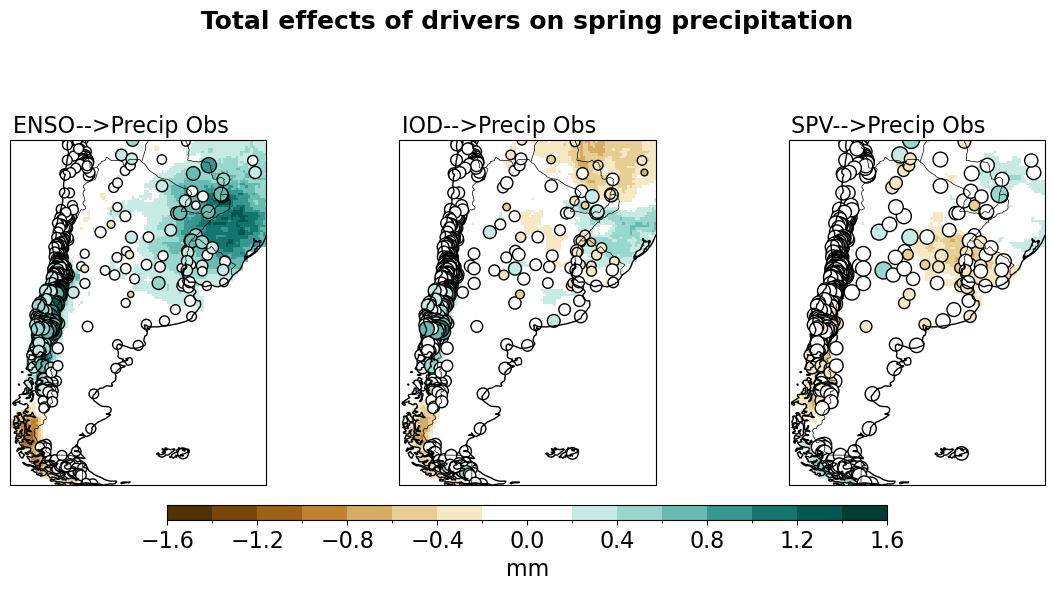

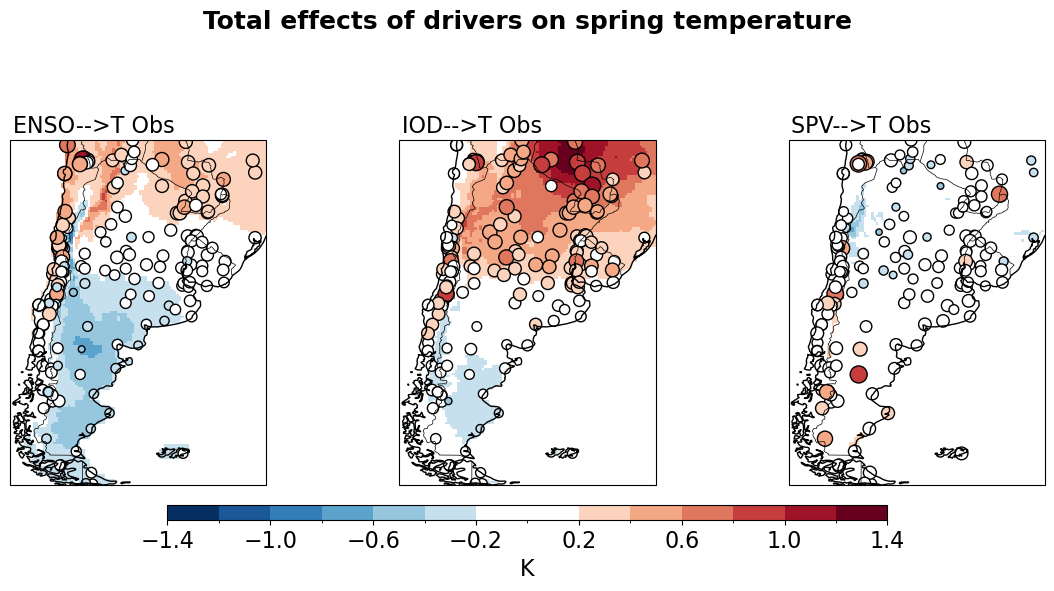

In [20]:
subplots_map(era5_reg_precip_SON_tot, title_pr_list_tot, cmap=plt.cm.BrBG, unit='mm', steps=.2, heading='Total effects of drivers on spring precipitation', \
             stations=precip_SON_tot)

subplots_map(era5_reg_temp_SON_tot, title_temp_list_tot, cmap=plt.cm.RdBu_r, unit='K', steps=.2, heading='Total effects of drivers on spring temperature', \
             stations=temp_SON_tot)

Summer analysis

In [21]:
era5_reg_precip_DJF=conditioning_everything_fast(ds_DJF, ['ENSO', 'IOBW', 'VB', 'A_SAM', 'S_SAM'], 
                                                 'tp')
era5_reg_temp_DJF=conditioning_everything_fast(ds_DJF, ['ENSO', 'IOBW', 'VB', 'A_SAM', 'S_SAM'], 
                                                 't2m')
era5_reg_temp_DJF_tot=conditioning_everything_fast(ds_DJF, ['ENSO', 'IOBW', 'VB'], 't2m', total_eff=True)
era5_reg_precip_DJF_tot=conditioning_everything_fast(ds_DJF, ['ENSO', 'IOBW', 'VB'], 'tp', total_eff=True)

ENSO done
IOBW done
VB done
A_SAM done
S_SAM done
ENSO done
IOBW done
VB done
A_SAM done
S_SAM done
ENSO done
IOBW done
VB done
ENSO done
IOBW done
VB done


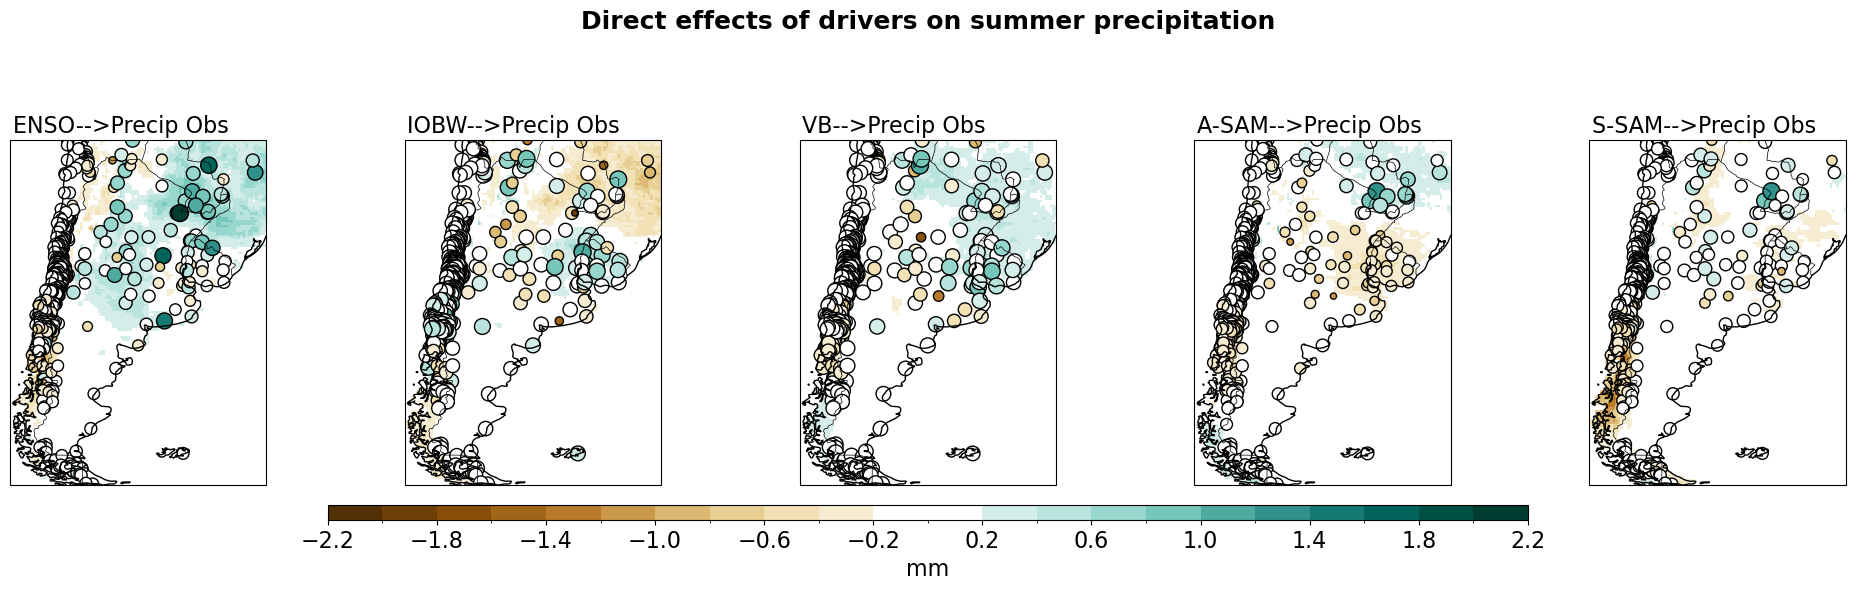

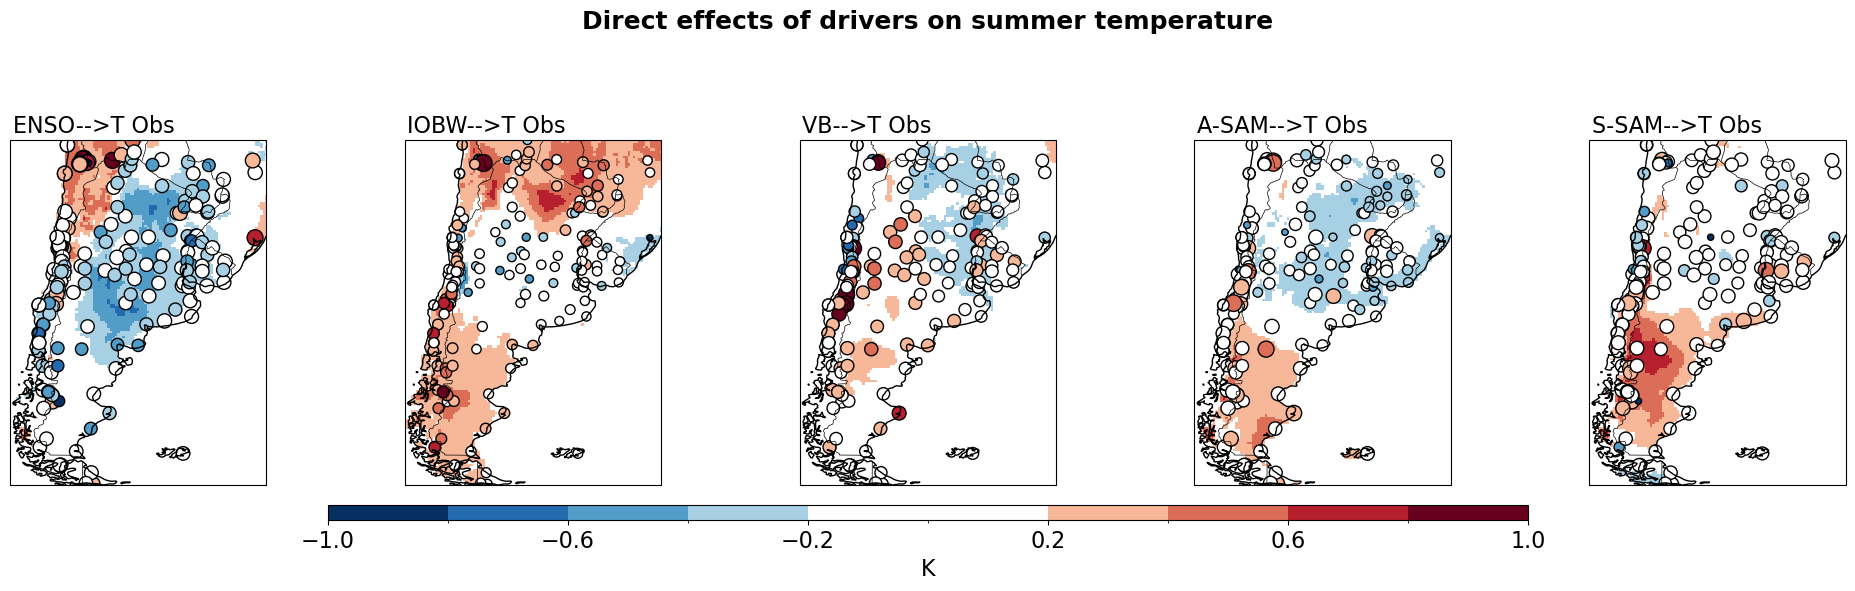

In [22]:
title_pr_summer_list=['ENSO-->Precip Obs', 'IOBW-->Precip Obs', 'VB-->Precip Obs', 'A-SAM-->Precip Obs', 
                      'S-SAM-->Precip Obs']
title_t_summer_list=['ENSO-->T Obs', 'IOBW-->T Obs', 'VB-->T Obs', 'A-SAM-->T Obs', 
                      'S-SAM-->T Obs']
subplots_map(era5_reg_precip_DJF, title_pr_summer_list, cmap=plt.cm.BrBG, unit='mm', steps=.2, heading='Direct effects of drivers on summer precipitation', \
             stations=precip_DJF_direct)

subplots_map(era5_reg_temp_DJF, title_t_summer_list, cmap=plt.cm.RdBu_r, unit='K', steps=.2, heading='Direct effects of drivers on summer temperature', \
             stations=temp_DJF_direct)

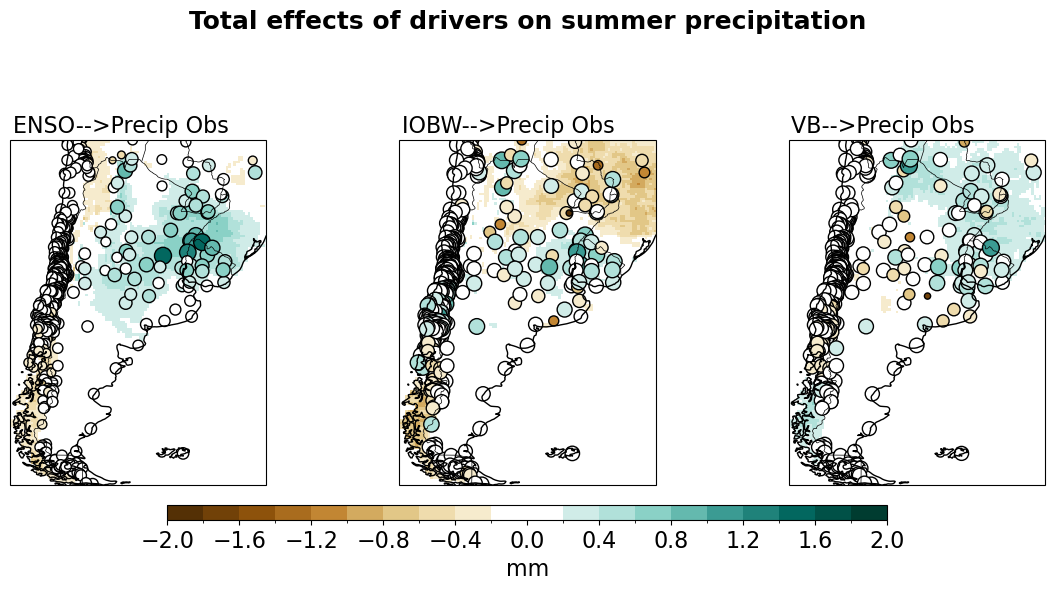

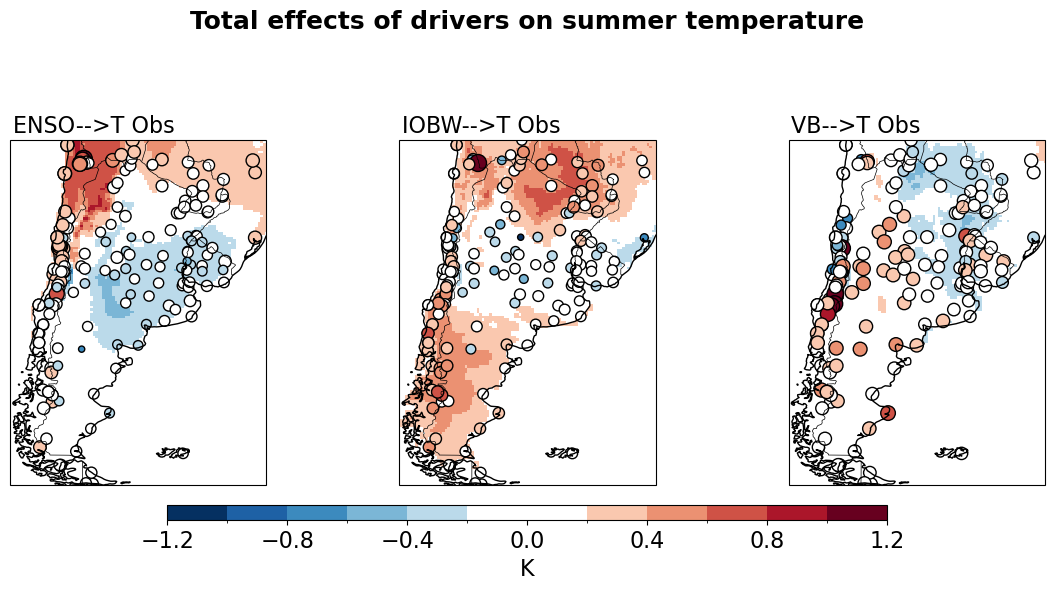

In [23]:
title_pr_summer_list_tot=['ENSO-->Precip Obs', 'IOBW-->Precip Obs', 'VB-->Precip Obs']
title_t_summer_list_tot=['ENSO-->T Obs', 'IOBW-->T Obs', 'VB-->T Obs']
subplots_map(era5_reg_precip_DJF_tot, title_pr_summer_list_tot, cmap=plt.cm.BrBG, unit='mm', steps=.2, heading='Total effects of drivers on summer precipitation', \
             stations=precip_DJF_tot)

subplots_map(era5_reg_temp_DJF_tot, title_t_summer_list_tot, cmap=plt.cm.RdBu_r, unit='K', steps=.2, heading='Total effects of drivers on summer temperature', \
             stations=temp_DJF_tot)